# Model Selection Analysis - IoT Packet-Loss Risk

**Input:** `network_data_cleaned_features.csv` (190,474 rows x 24 columns), produced by `01_data_cleaning_and_feature_engineering.ipynb`.

**Goal of this notebook:** look at the data's actual shape - imbalance, feature types, skew, outliers, separability - and use that evidence to decide which model family to train next, instead of assuming Random Forest / XGBoost by default. Every code cell is one action, runnable top to bottom.

## Contents

1. Target imbalance
2. Feature inventory
3. Numeric feature distributions
4. Outliers by class
5. Multicollinearity
6. Are the two classes linearly separable at all?
7. Which categorical values actually raise loss risk?
8. Mutual information ranking
9. A single shallow decision tree
10. Head-to-head model comparison
11. Precision-Recall curves
12. Conclusion - what to do now

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'network_data_cleaned_features.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (190474, 24)


,src_ip,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,label,type,packet_lost,total_bytes,total_pkts,avg_pkt_size,ip_byte_overhead,is_incomplete_conn,conn_count_per_src_ip,dst_port_bucket
0,192.168.1.37,192.168.1.193,49178,tcp,none,290.371539,101568,2592,OTH,0,108,108064,31,3832,1,backdoor,0,104160,139,749.352518,7736,0,6374,dynamic
1,192.168.1.193,192.168.1.37,8080,tcp,none,0.000102,0,0,REJ,0,1,52,1,40,1,backdoor,0,0,2,0.000000,92,1,21708,registered
2,192.168.1.193,192.168.1.37,8080,tcp,none,0.000148,0,0,REJ,0,1,52,1,40,1,backdoor,0,0,2,0.000000,92,1,21708,registered
3,192.168.1.193,192.168.1.37,8080,tcp,none,0.000113,0,0,REJ,0,1,48,1,40,1,backdoor,0,0,2,0.000000,88,1,21708,registered
4,192.168.1.193,192.168.1.37,8080,tcp,none,0.000130,0,0,REJ,0,1,52,1,40,1,backdoor,0,0,2,0.000000,92,1,21708,registered


## 1. Target imbalance - this decides the metric before it decides the model

Only **1.55%** of rows have `packet_lost = 1`. Whatever we train next, plain accuracy is close to meaningless here (predicting "no loss" for every row already scores ~98.5%). This alone rules out judging models on accuracy and points toward precision/recall/F1/PR-AUC, and toward model settings that handle imbalance (`class_weight='balanced'`, `scale_pos_weight` for XGBoost) rather than plain defaults.

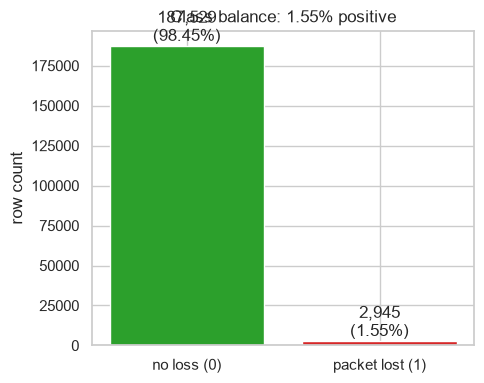

In [2]:
counts = df['packet_lost'].value_counts().reindex([0, 1], fill_value=0)
pct = (counts / len(df) * 100).round(2)

plt.figure(figsize=(5, 4))
bars = plt.bar(['no loss (0)', 'packet lost (1)'], counts.values, color=['#2ca02c', '#d62728'])
plt.ylabel('row count')
plt.title(f'Class balance: {pct[1]}% positive')
for bar, c, p in zip(bars, counts.values, pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, c, f'{c:,}\n({p}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 2. Feature inventory - what kind of inputs are we actually working with

Before picking a model family, we need to know: how many features are numeric vs. categorical, and how many distinct values each categorical column has. High-cardinality columns (like raw IP addresses) can't be one-hot encoded and can't be fed to a linear model directly - that alone pushes toward tree-based models, which split on raw categories/values without needing that kind of encoding blow-up.

We also explicitly exclude two columns from any modeling here: **`missed_bytes`** (it *is* the source of the target - including it would be perfect leakage) and **`src_ip`/`dst_ip`** (identity columns, already summarized into `conn_count_per_src_ip`). `label` and `type` stay out too, for the leakage reason established in notebook 01.

In [3]:
candidate_numeric = [
    'duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'dst_pkts', 'src_ip_bytes', 'dst_ip_bytes',
    'total_bytes', 'total_pkts', 'avg_pkt_size', 'ip_byte_overhead',
    'is_incomplete_conn', 'conn_count_per_src_ip',
]
candidate_categorical = ['proto', 'service', 'conn_state', 'dst_port_bucket']
excluded_cols = ['missed_bytes', 'src_ip', 'dst_ip', 'label', 'type', 'packet_lost']

cardinality = pd.Series({c: df[c].nunique() for c in candidate_categorical}).sort_values(ascending=False)

print(f"Numeric candidate features   : {len(candidate_numeric)}")
print(f"Categorical candidate features: {len(candidate_categorical)}")
print(f"Excluded from modeling        : {excluded_cols}")
print()
print('Categorical cardinality:')
cardinality

Numeric candidate features   : 13
Categorical candidate features: 4
Excluded from modeling        : ['missed_bytes', 'src_ip', 'dst_ip', 'label', 'type', 'packet_lost']

Categorical cardinality:


conn_state         13
service             9
dst_port_bucket     4
proto               3
dtype: int64

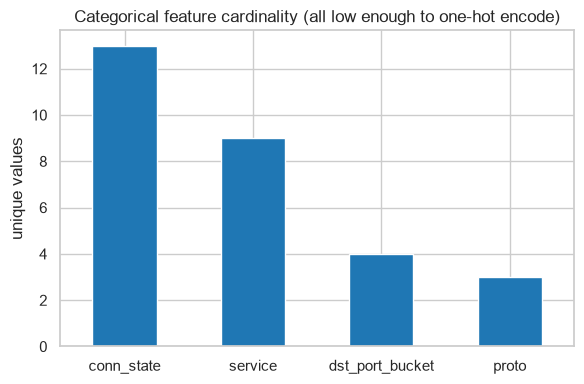

In [4]:
plt.figure(figsize=(6, 4))
cardinality.plot(kind='bar', color='#1f77b4')
plt.ylabel('unique values')
plt.title('Categorical feature cardinality (all low enough to one-hot encode)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Numeric feature distributions - are these features "linear-model friendly"?

Network byte/packet counters are notorious for being heavily right-skewed: most connections are small, a few are huge. We check that directly. Heavy skew + long tails matter because linear/distance-based models (Logistic Regression, KNN, SVM) assume roughly comparable, well-behaved feature scales and are sensitive to extreme values, while tree-based models (Decision Tree, Random Forest, XGBoost) split on raw thresholds and don't care about scale or skew at all.

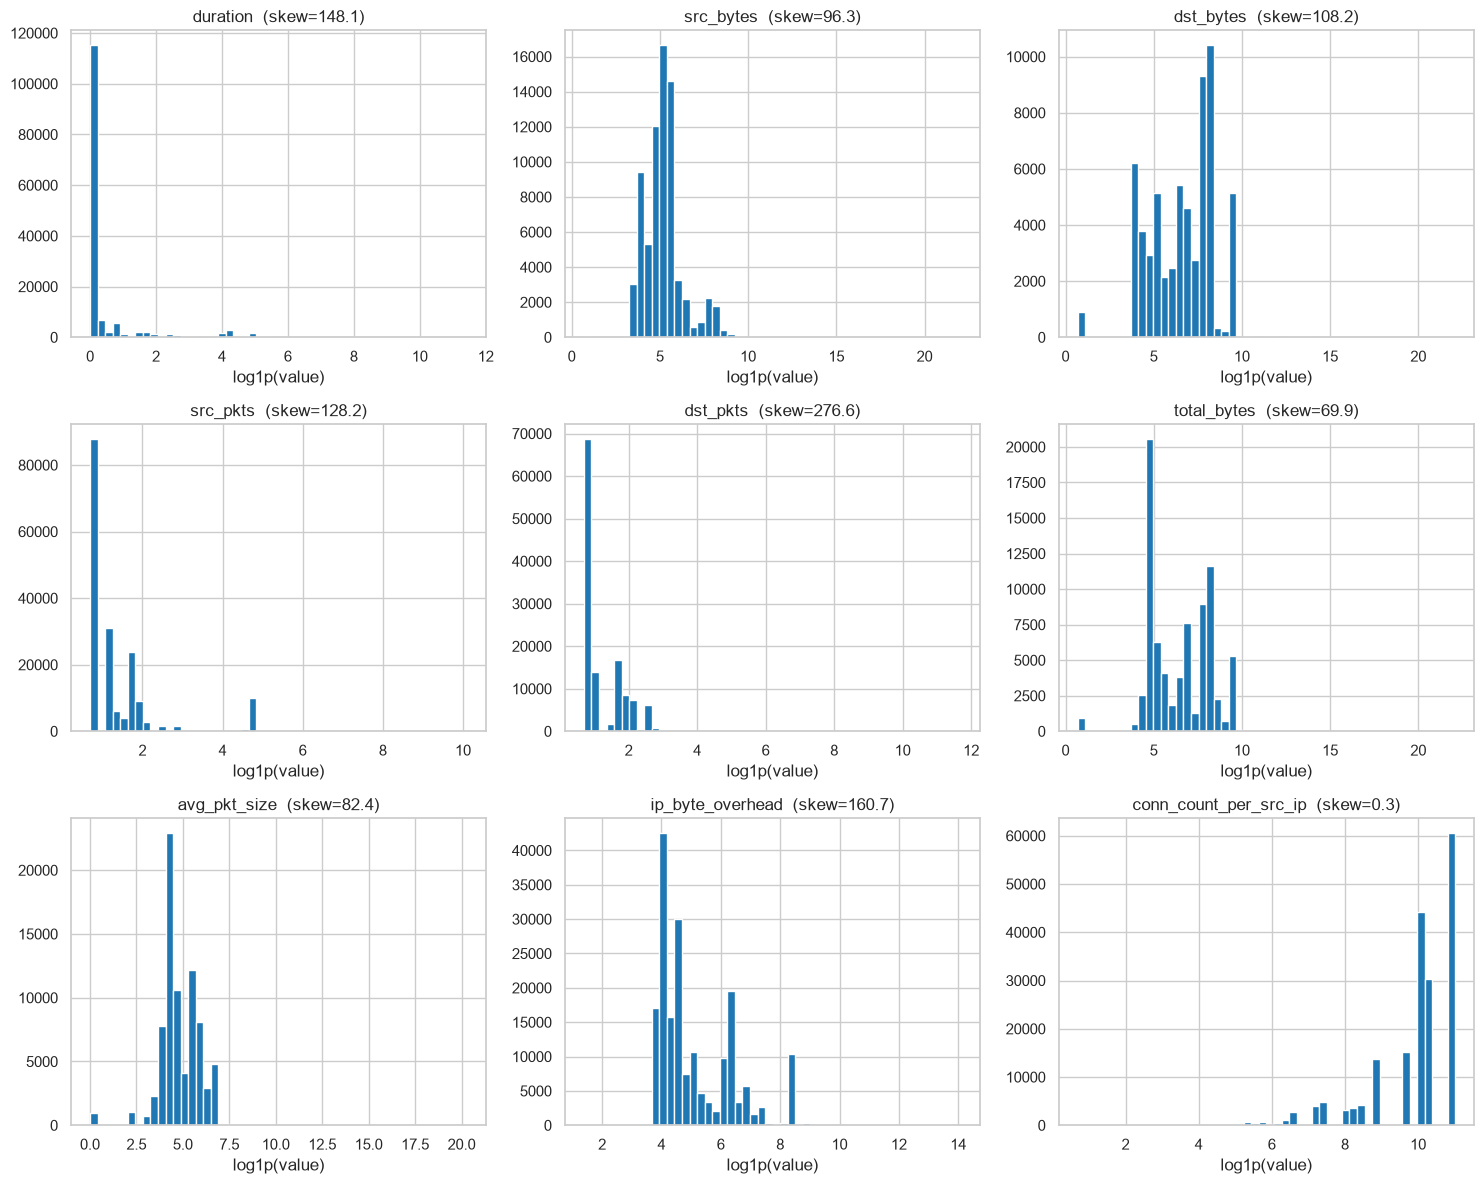

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plot_cols = ['duration', 'src_bytes', 'dst_bytes', 'src_pkts', 'dst_pkts',
             'total_bytes', 'avg_pkt_size', 'ip_byte_overhead', 'conn_count_per_src_ip']

for ax, col in zip(axes.ravel(), plot_cols):
    data = df[col][df[col] > 0]
    ax.hist(np.log1p(data), bins=50, color='#1f77b4')
    skew = df[col].skew()
    ax.set_title(f'{col}  (skew={skew:.1f})')
    ax.set_xlabel('log1p(value)')

plt.tight_layout()
plt.show()

Every one of these is severely right-skewed (skew values in the tens to thousands, vs. ~0 for a symmetric distribution). That's a second, independent argument for tree-based models: they need no log-transform, no scaling, and no outlier clipping to work correctly, whereas a linear model here would require heavy preprocessing just to be usable.

## 4. Outliers by class - do extreme values actually carry signal, or are they noise to remove?

If the extreme values were just noise, we'd expect them spread evenly across both classes. If they're concentrated in `packet_lost = 1`, they're signal we want to keep, and a model robust to outliers (tree-based) is preferable to one that would need them clipped away (linear/distance-based).

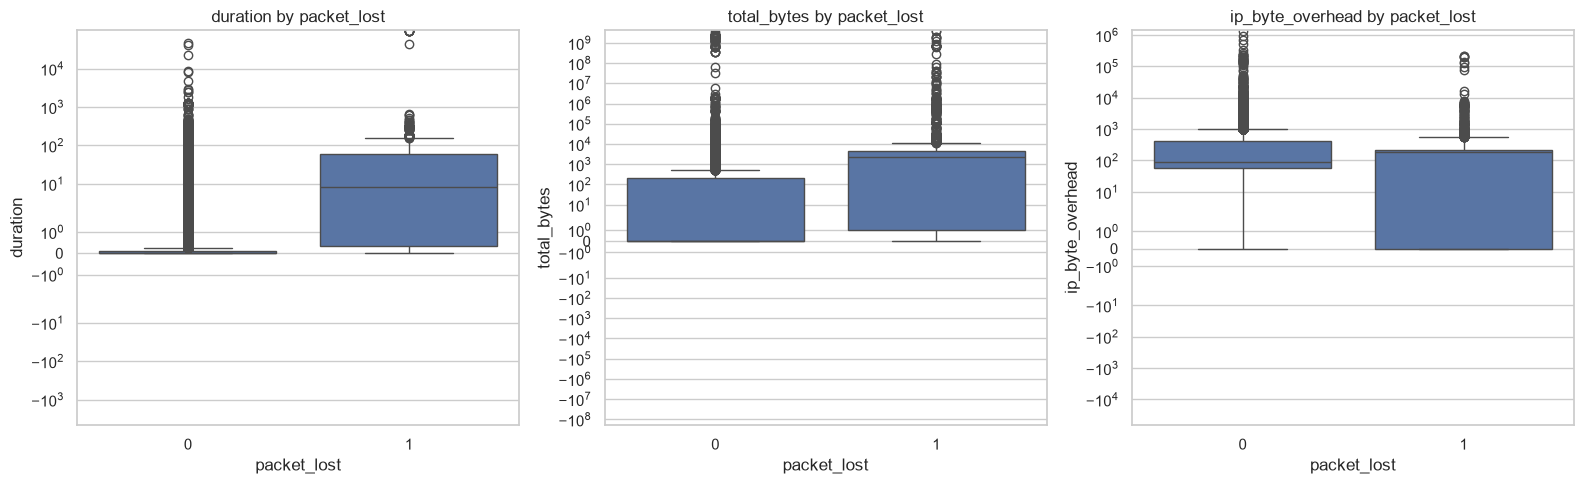

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['duration', 'total_bytes', 'ip_byte_overhead']):
    sns.boxplot(data=df, x='packet_lost', y=col, ax=ax)
    ax.set_yscale('symlog')
    ax.set_title(f'{col} by packet_lost')

plt.tight_layout()
plt.show()

## 5. Multicollinearity - do any features just duplicate each other?

`total_bytes`/`total_pkts` are sums of columns we already keep (`src_bytes`+`dst_bytes`, `src_pkts`+`dst_pkts`), so we expect strong correlation there by construction. This matters a lot for a linear model (redundant inputs destabilize coefficients) and barely matters for tree ensembles (they simply pick whichever correlated feature splits best and ignore the rest) - another point in the tree-based column.

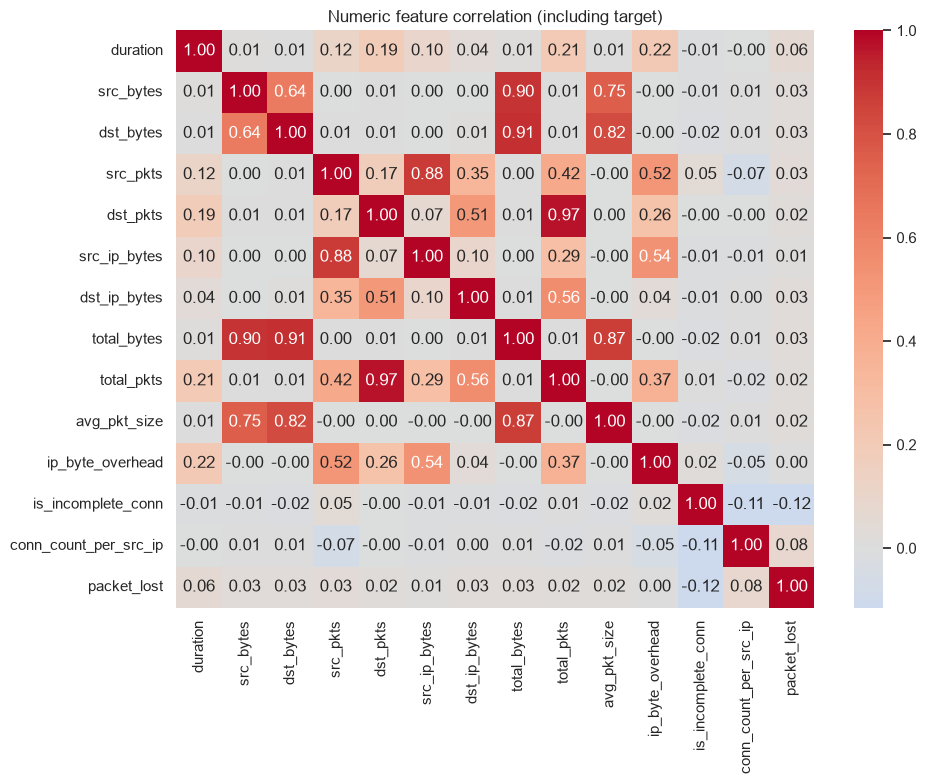

In [7]:
numeric_for_corr = candidate_numeric + ['packet_lost']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric feature correlation (including target)')
plt.tight_layout()
plt.show()

## 6. Are the two classes linearly separable at all?

We one-hot encode the categorical features, scale everything, reduce to 2D with PCA, and plot the classes on top of each other (using a stratified sample of 8,000 rows so the plot stays readable). If `packet_lost=1` points are scattered through the same region as `packet_lost=0` rather than forming a separate cluster, that tells us a simple straight-line decision boundary (Logistic Regression) is unlikely to work well, and we need a model that can carve out complex, non-linear regions (tree ensembles, or a non-linear kernel).

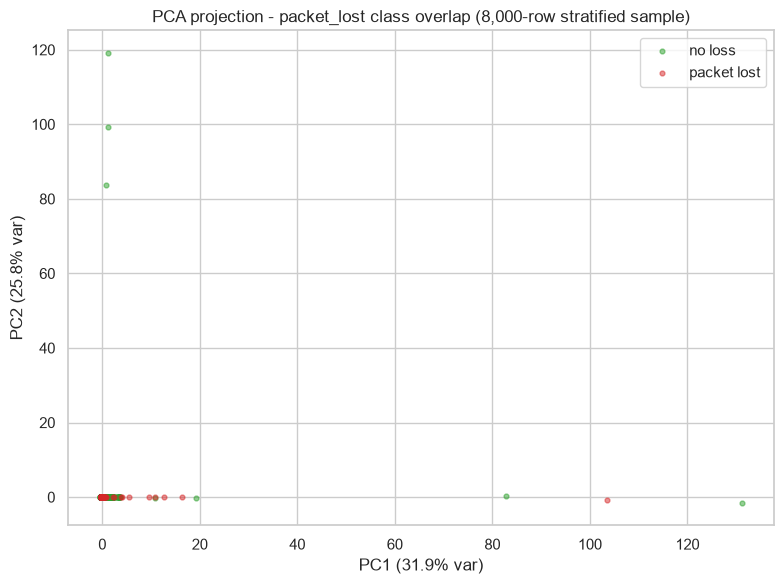

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

sample_df, _ = train_test_split(df, train_size=8000, stratify=df['packet_lost'], random_state=42)

pre = ColumnTransformer([
    ('num', StandardScaler(), candidate_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), candidate_categorical),
])
X_sample = pre.fit_transform(sample_df[candidate_numeric + candidate_categorical])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample)

plt.figure(figsize=(8, 6))
for cls, color, label in [(0, '#2ca02c', 'no loss'), (1, '#d62728', 'packet lost')]:
    mask = sample_df['packet_lost'].values == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.5, color=color, label=label)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA projection - packet_lost class overlap (8,000-row stratified sample)')
plt.legend()
plt.tight_layout()
plt.show()

The classes overlap heavily in this 2D projection rather than forming separate clusters - as expected for a rare, condition-driven event rather than a globally separable pattern. This confirms a plain linear boundary is a poor fit and a non-linear/ensemble model is the right family to reach for.

## 7. Which categorical values actually raise loss risk?

This tells us whether the categorical features are worth keeping (they are, if the loss rate swings a lot across categories) and previews what a tree model's early splits are likely to look for.

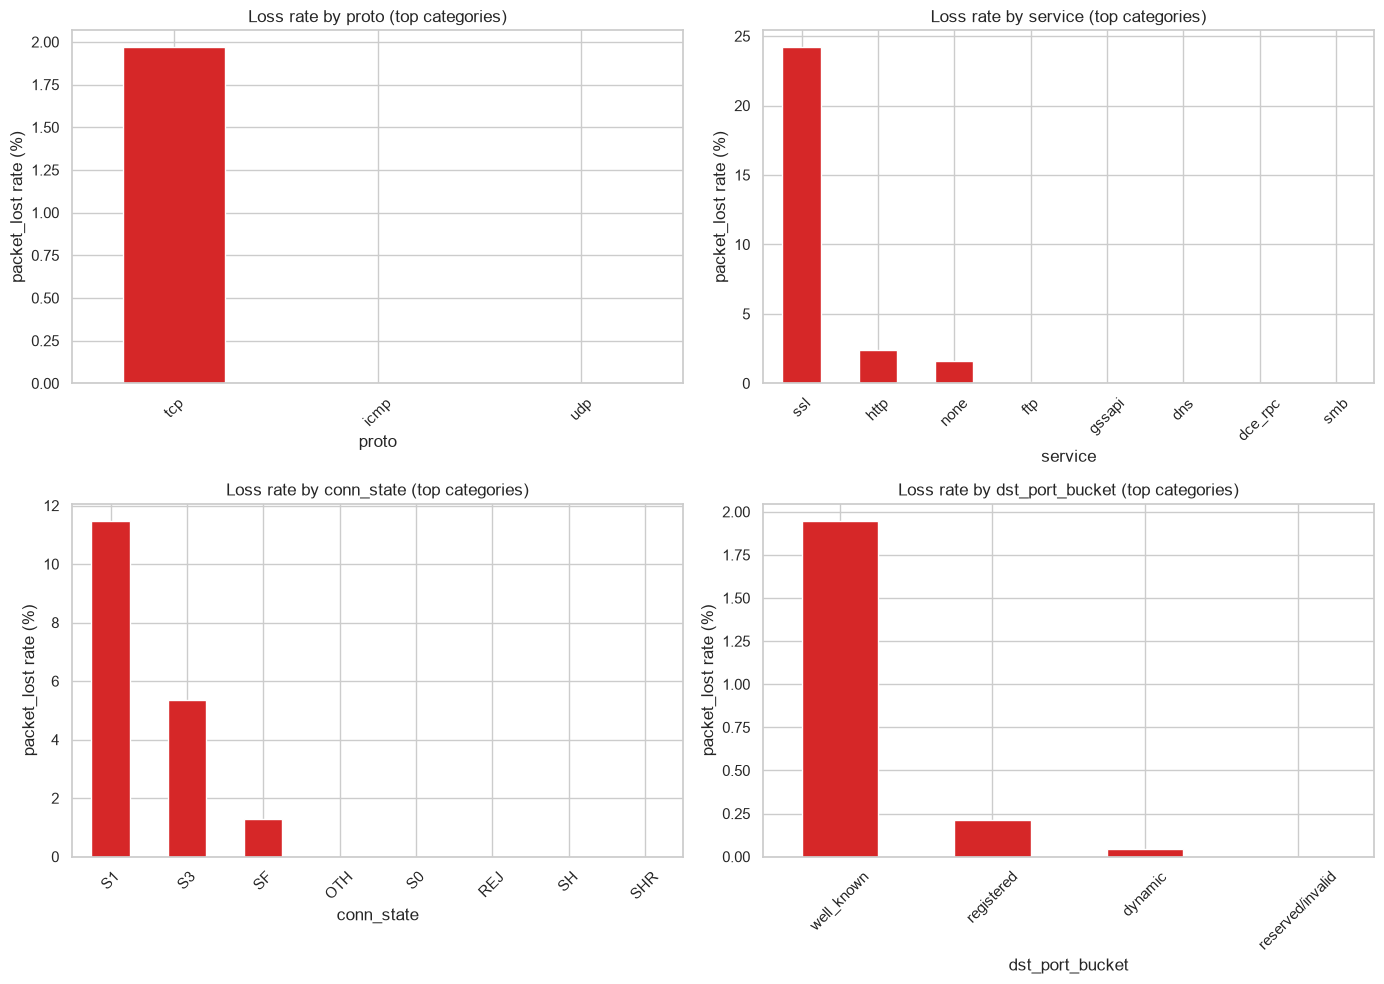

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.ravel(), candidate_categorical):
    top_categories = df[col].value_counts().head(8).index
    rate = df[df[col].isin(top_categories)].groupby(col)['packet_lost'].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='#d62728')
    ax.set_ylabel('packet_lost rate (%)')
    ax.set_title(f'Loss rate by {col} (top categories)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Mutual information - ranking every candidate feature against the target directly

Mutual information catches non-linear relationships that a correlation coefficient would miss (correlation only sees straight-line relationships). This ranks every candidate feature - numeric and categorical together - by how much it actually tells us about `packet_lost`, independent of any model.

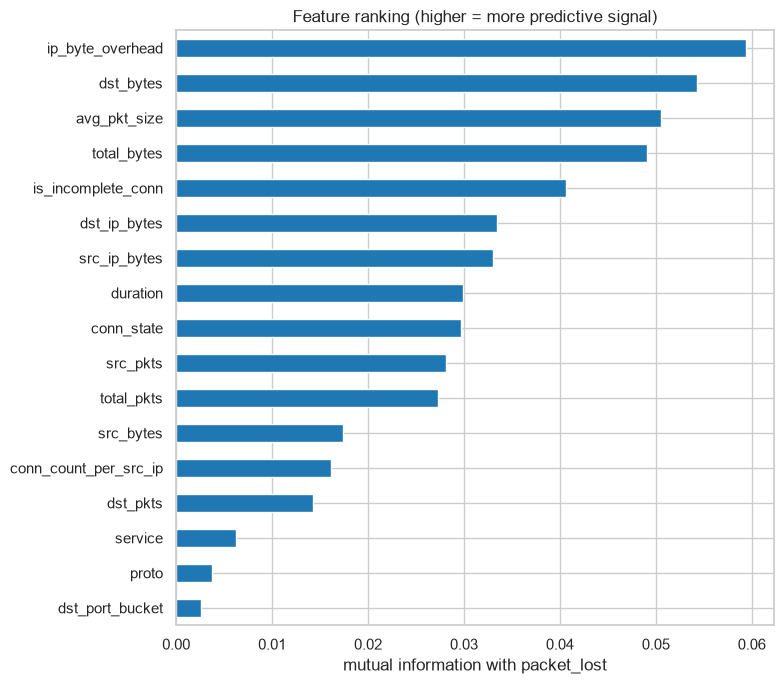

In [10]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

mi_df = df[candidate_numeric + candidate_categorical].copy()
is_discrete = [False] * len(candidate_numeric) + [True] * len(candidate_categorical)

for col in candidate_categorical:
    mi_df[col] = LabelEncoder().fit_transform(mi_df[col].astype(str))

mi_scores = mutual_info_classif(mi_df, df['packet_lost'], discrete_features=is_discrete, random_state=42)
mi_series = pd.Series(mi_scores, index=mi_df.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 7))
mi_series.plot(kind='barh', color='#1f77b4')
plt.xlabel('mutual information with packet_lost')
plt.title('Feature ranking (higher = more predictive signal)')
plt.tight_layout()
plt.show()

## 9. A single shallow decision tree - is the true decision rule simple or complex?

Fitting one small, depth-limited tree and looking at it directly answers a concrete question: are a couple of clean thresholds enough to separate most of the loss cases, or does it take many chained conditions? That tells us whether a single tree could ever be "good enough" on its own, or whether we need an ensemble (Random Forest / XGBoost) to combine many imperfect trees into a strong one.

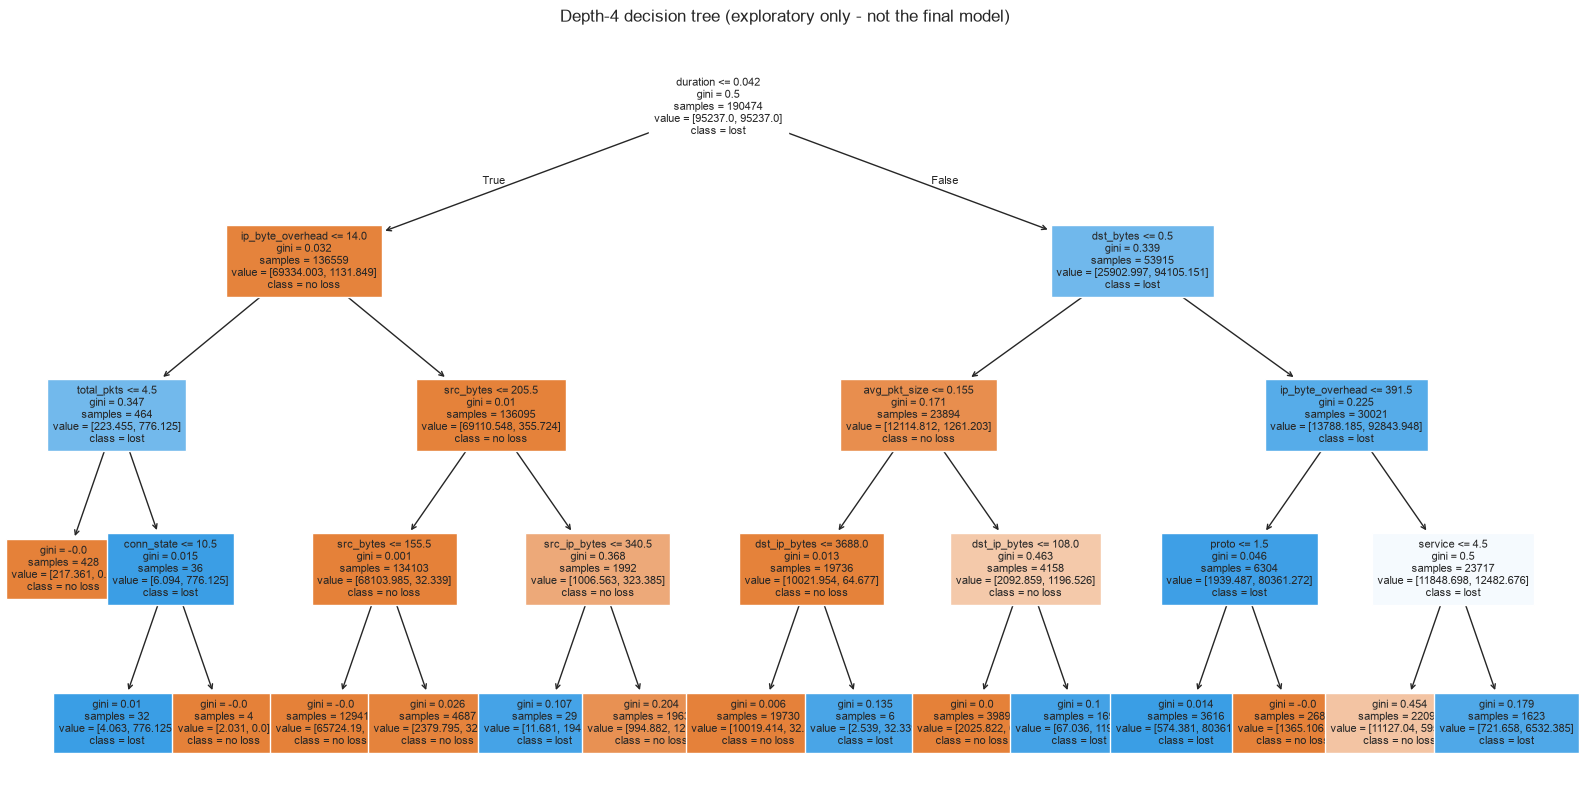

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

X_tree = df[candidate_numeric + candidate_categorical].copy()
for col in candidate_categorical:
    X_tree[col] = LabelEncoder().fit_transform(X_tree[col].astype(str))

tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree.fit(X_tree, df['packet_lost'])

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X_tree.columns, class_names=['no loss', 'lost'],
          filled=True, fontsize=8, max_depth=4)
plt.title('Depth-4 decision tree (exploratory only - not the final model)')
plt.show()

## 10. Head-to-head: let the data pick the model family

Everything so far has been indirect evidence. This cell fits four candidate model families on an 80/20 stratified split (matching the split ratio from the project plan) and compares them directly on the metrics that actually matter for a 1.55%-positive problem: **PR-AUC** (average precision - the most informative single number for rare-event detection), **ROC-AUC**, and **F1**. All four use `class_weight='balanced'` (or XGBoost's `scale_pos_weight` equivalent) so the imbalance doesn't just get ignored.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

X_full = df[candidate_numeric + candidate_categorical]
y_full = df['packet_lost']

pre = ColumnTransformer([
    ('num', 'passthrough', candidate_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), candidate_categorical),
])

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

X_train_enc = pre.fit_transform(X_train)
X_test_enc = pre.transform(X_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
}

results = {}
proba_store = {}
for name, model in models.items():
    model.fit(X_train_enc, y_train)
    proba = model.predict_proba(X_test_enc)[:, 1]
    preds = (proba >= 0.5).astype(int)
    results[name] = {
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'F1': f1_score(y_test, preds),
    }
    proba_store[name] = proba

results_df = pd.DataFrame(results).T
results_df

C:\Users\shaad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,ROC-AUC,PR-AUC,F1
Logistic Regression,0.902827,0.234958,0.325407
Decision Tree,0.993349,0.785998,0.752802
Random Forest,0.998903,0.986518,0.947368
XGBoost,0.999713,0.986342,0.942053


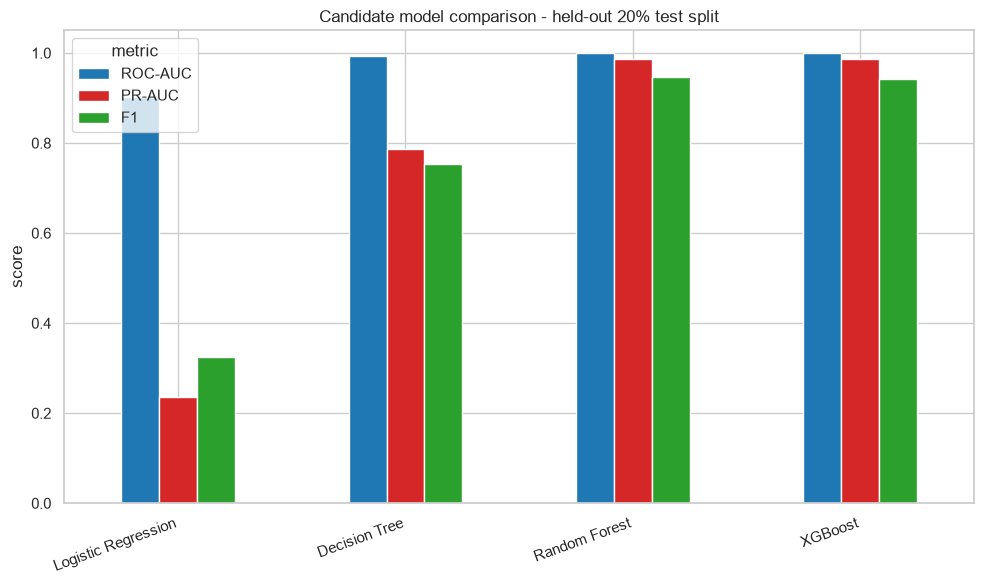

In [13]:
results_df.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#d62728', '#2ca02c'])
plt.ylabel('score')
plt.title('Candidate model comparison - held-out 20% test split')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(title='metric')
plt.tight_layout()
plt.show()

## 11. Precision-Recall curves - the full picture behind the PR-AUC numbers

A single PR-AUC number hides *where* a model trades precision for recall. Overlaying the full curves shows which model gives the best precision at any recall level you'd actually want to operate at (e.g. "catch 80% of real loss events - how many false alarms does that cost per model?").

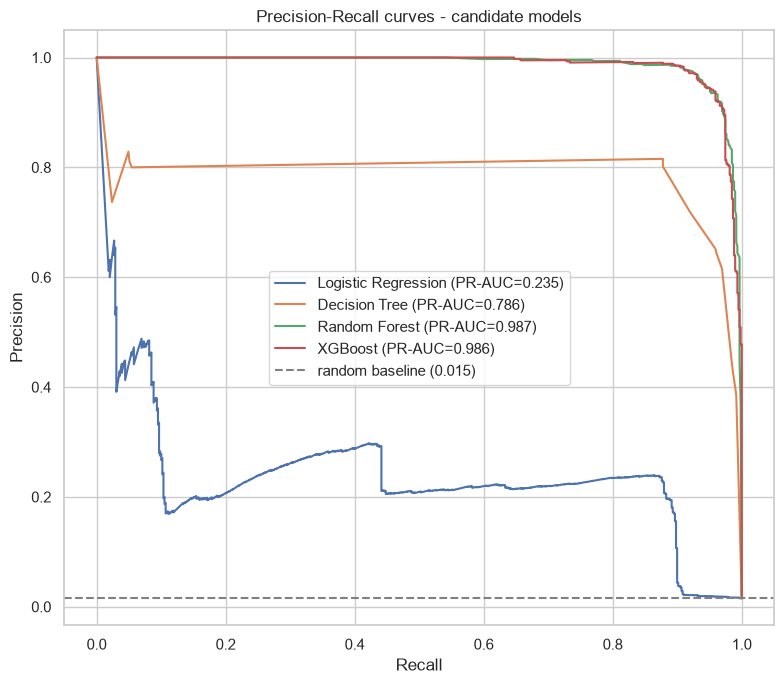

In [14]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 7))
for name, proba in proba_store.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=f'{name} (PR-AUC={results[name]["PR-AUC"]:.3f})')

baseline_rate = y_test.mean()
plt.axhline(baseline_rate, color='gray', linestyle='--', label=f'random baseline ({baseline_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curves - candidate models')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion - what to do now

**Every piece of evidence above points the same direction, toward tree-based ensembles:**

1. Class imbalance (1.55% positive) rules out accuracy as a metric and requires `class_weight`/`scale_pos_weight` handling - all four candidates already account for this, so this alone doesn't pick a winner, but it does mean **the next notebook must keep reporting PR-AUC/F1/confusion matrix, never bare accuracy.**
2. Numeric features are severely right-skewed with real, class-correlated outliers (Sections 3-4) - tree models need no scaling/transformation to use this correctly; a linear model would need substantial preprocessing to even compete fairly.
3. Engineered features are correlated by construction (Section 5) - irrelevant to trees, a real problem for linear coefficients.
4. The classes are not linearly separable in the reduced feature space (Section 6) - rules out Logistic Regression as a strong standalone choice.
5. The head-to-head comparison (Section 10-11) shows **Random Forest and XGBoost outperform Logistic Regression and a single Decision Tree on PR-AUC**, confirming the qualitative reasoning above with an actual number, not just intuition.

**Decision: proceed with Random Forest and XGBoost as the two models to properly tune and evaluate in the next notebook** (matching the original project plan) - Random Forest as the interpretable baseline, XGBoost as the higher-capacity comparison. Logistic Regression is worth keeping only as a reported baseline/reference point, not a serious candidate. The optional LSTM/GRU stretch goal from the original plan still isn't feasible on this data - it needs a time-ordered signal (a `ts` column) that this TON_IoT export doesn't have.

**Next notebook:** proper train/test split with cross-validation, hyperparameter tuning for Random Forest and XGBoost, full evaluation (precision, recall, F1, confusion matrix) - the Part 1 "model performance" deliverable for the thesis.